In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from pandas.plotting import parallel_coordinates
iris = load_iris()

Kode ini digunakan untuk mengimpor library yang dibutuhkan dalam analisis data. numpy dan pandas digunakan untuk mengolah data, sedangkan matplotlib digunakan untuk membuat grafik. load_iris digunakan untuk mengambil dataset Iris dari Scikit-learn, lalu dataset tersebut disimpan dalam variabel iris.

In [2]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["Species"] = iris.target_names[iris.target]
X = df.drop(columns=["Species"])
y = df["Species"]
print(X)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]


Kode ini mengubah dataset Iris menjadi DataFrame dengan nama kolom sesuai fitur bunga. Kolom Species ditambahkan untuk menunjukkan jenis bunga. Selanjutnya, X berisi data fitur sebagai data input, sedangkan y berisi jenis spesies sebagai target. print(X) digunakan untuk menampilkan data fitur tersebut.


In [3]:
y

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: Species, Length: 150, dtype: str

Output y menampilkan jenis bunga dari dataset Iris. Terlihat data pertama sampai indeks 4 adalah setosa, sedangkan data terakhir adalah virginica. Total terdapat 150 data dan tipe datanya berupa teks (str).


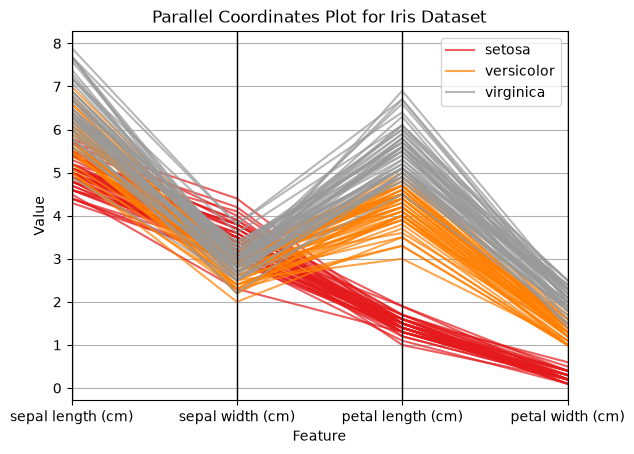

In [5]:
parallel_coordinates(df, class_column="Species", colormap=plt.cm.Set1, alpha=0.7)
plt.title("Parallel Coordinates Plot for Iris Dataset")
plt.xlabel("Feature")
plt.ylabel("Value")
plt.grid(True)
plt.show()

Kode ini membuat grafik parallel coordinates untuk melihat perbedaan karakteristik setiap jenis bunga Iris berdasarkan fitur-fiturnya. Grafik diberi judul, nama sumbu, garis grid, dan warna yang berbeda untuk setiap jenis bunga agar lebih mudah dibandingkan. plt.show() digunakan untuk menampilkan grafik.

In [6]:
from sklearn.preprocessing import LabelEncoder
lab = LabelEncoder()
y = lab.fit_transform(y)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

Kode ini mengubah data jenis bunga yang awalnya berupa teks menjadi angka agar bisa diproses oleh model machine learning. LabelEncoder memberikan kode angka untuk setiap jenis bunga, misalnya setosa, versicolor, dan virginica. Hasil akhirnya disimpan kembali ke variabel y.


In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(X, test_size=0.2, random_state=0)
y_train, y_test = train_test_split(y, test_size=0.2, random_state=0)

Kode ini membagi data menjadi data latih (training) dan data uji (testing) dengan perbandingan 80:20. X_train dan y_train digunakan untuk melatih model, sedangkan X_test dan y_test digunakan untuk menguji hasil prediksi model. random_state=0 membuat pembagian data tetap sama setiap kali kode dijalankan.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean')

knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


Kode ini membuat model K-Nearest Neighbors (KNN) dengan jumlah 3 tetangga terdekat dan menggunakan jarak Euclidean untuk menghitung kedekatan data. Kemudian, knn.fit() digunakan untuk melatih model menggunakan data latih X_train` dan y_train.


In [9]:
y_pred = knn.predict(X_test)
y_pred

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 1, 1, 2, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0])

Kode ini menggunakan model KNN yang sudah dilatih untuk memprediksi jenis bunga berdasarkan data uji X_test. Hasil prediksi disimpan dalam y_pred, lalu ditampilkan untuk melihat hasil klasifikasi dari setiap data uji.

In [10]:
result = accuracy_score(y_test, y_pred)
result

0.9666666666666667

Kode ini menghitung tingkat akurasi model KNN dengan membandingkan hasil prediksi y_pred dengan data sebenarnya y_test. Hasilnya disimpan dalam result untuk mengetahui seberapa tepat model dalam mengklasifikasikan data.

In [12]:
df = pd.read_csv('athletes.xls')
print(df)

    id  speed  agility draft
0    1   2.50     6.00    no
1    2   3.75     8.00    no
2    3   2.25     5.50    no
3    4   3.25     8.25    no
4    5   2.75     7.50    no
5    6   4.50     5.00    no
6    7   3.50     5.25    no
7    8   3.00     3.25    no
8    9   4.00     4.00    no
9   10   4.25     3.75    no
10  11   2.00     2.00    no
11  12   5.00     2.50    no
12  13   8.25     8.50    no
13  14   5.75     8.75   yes
14  15   4.75     6.25   yes
15  16   5.50     6.75   yes
16  17   5.25     9.50   yes
17  18   7.00     4.25   yes
18  19   7.50     8.00   yes
19  20   7.25     5.75   yes


Kode ini membaca dataset athletes.xls menggunakan pandas dan menyimpannya ke dalam variabel df. Kemudian, print(df) digunakan untuk menampilkan seluruh data atlet yang terdapat dalam dataset.

In [13]:
feature_columns = ['speed', 'agility']
X = df[feature_columns].values
y = df['draft'].values

Kode ini menentukan fitur yang digunakan untuk klasifikasi, yaitu speed dan agility, lalu menyimpannya sebagai data input X. Sementara itu, kolom draft digunakan sebagai target atau hasil yang ingin diprediksi dan disimpan dalam y.

In [15]:
X

array([[2.5 , 6.  ],
       [3.75, 8.  ],
       [2.25, 5.5 ],
       [3.25, 8.25],
       [2.75, 7.5 ],
       [4.5 , 5.  ],
       [3.5 , 5.25],
       [3.  , 3.25],
       [4.  , 4.  ],
       [4.25, 3.75],
       [2.  , 2.  ],
       [5.  , 2.5 ],
       [8.25, 8.5 ],
       [5.75, 8.75],
       [4.75, 6.25],
       [5.5 , 6.75],
       [5.25, 9.5 ],
       [7.  , 4.25],
       [7.5 , 8.  ],
       [7.25, 5.75]])

Output `X` menampilkan data fitur yang digunakan dalam model, yaitu speed dan agility. Setiap baris menunjukkan nilai kecepatan dan kelincahan dari satu atlet yang akan digunakan untuk proses klasifikasi.

In [16]:
y

<ArrowStringArray>
[ 'no',  'no',  'no',  'no',  'no',  'no',  'no',  'no',  'no',  'no',  'no',
  'no',  'no', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes']
Length: 20, dtype: str

Output y berisi target yang akan diprediksi oleh model, yaitu status draft atlet. Terdapat 20 data, dengan nilai no untuk atlet yang tidak terpilih dan yes untuk atlet yang terpilih.

In [17]:
en = LabelEncoder()
y = en.fit_transform(y)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1])

Kode ini mengubah data target yang awalnya berupa teks yes dan no menjadi angka menggunakan LabelEncoder. Hasilnya disimpan kembali ke y agar data dapat diproses oleh model KNN.

['r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'g' 'g' 'g' 'g' 'g'
 'g' 'g']


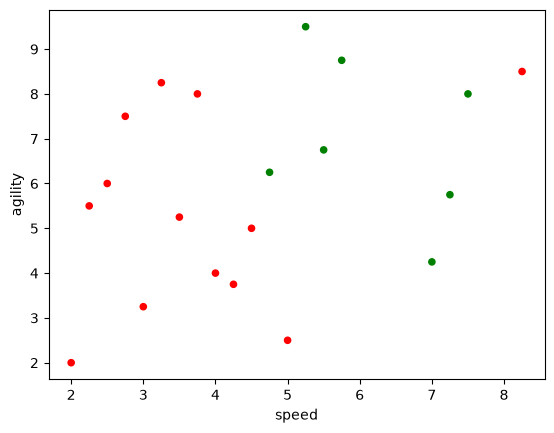

In [18]:
from numpy import where
df['key1'] = (y)
colors = np.where(df["key1"]==0,'r','g')
print(colors)
df.plot.scatter(x=1,y=2,c=colors)
plt.show()

Kode ini memberi warna pada data berdasarkan status draft: merah untuk nilai 0 (no) dan hijau untuk nilai 1 (yes). Setelah itu, data ditampilkan dalam bentuk scatter plot untuk melihat persebaran data berdasarkan dua fitur yang digunakan.

In [19]:
X_train, X_test = train_test_split(X, test_size=0.2, random_state=0)
y_train, y_test = train_test_split(y, test_size=0.2, random_state=0)

Kode ini membagi data menjadi data latih 80% dan data uji 20%. X_train dan y_train digunakan untuk melatih model, sedangkan X_test dan y_test digunakan untuk menguji hasil prediksi. random_state=0 membuat pembagian data tetap sama setiap kali dijalankan.

In [20]:
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train, y_train)

,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


Kode ini membuat model KNN dengan 5 tetangga terdekat menggunakan jarak Euclidean. Kemudian, knn.fit() digunakan untuk melatih model menggunakan data latih X_train dan y_train.

In [21]:
y_pred = knn.predict(X_test)
y_pred

array([1, 1, 1, 0])

Kode ini menggunakan model KNN yang sudah dilatih untuk memprediksi status draft berdasarkan data uji X_test. Hasil prediksi disimpan dalam y_pred, kemudian ditampilkan untuk melihat hasil klasifikasi setiap data uji.


In [22]:
result = accuracy_score(y_test, y_pred)
result

0.75

Kode ini menghitung akurasi model KNN dengan membandingkan hasil prediksi y_pred dengan data sebenarnya y_test. Hasil perhitungannya disimpan dalam result untuk mengetahui seberapa tepat model dalam memprediksi status draft atlet.

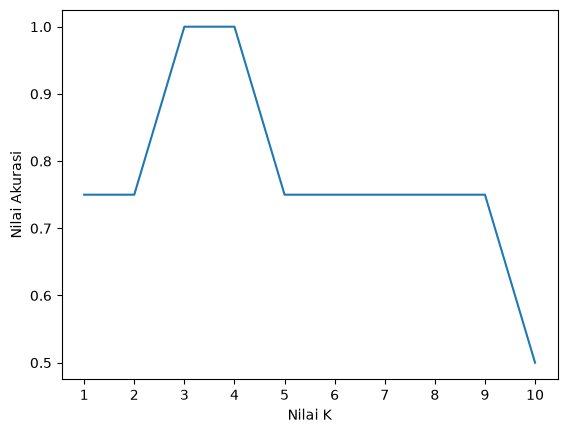

In [23]:
array_k = []
for i in range(1,11):
  knn = KNeighborsClassifier(n_neighbors=i, metric='euclidean')
  knn.fit(X_train, y_train)
  y_pred = knn.predict(X_test)
  result = accuracy_score(y_test, y_pred)
  array_k.append(result)
plt.plot(array_k)
plt.ylabel('Nilai Akurasi')
plt.xlabel('Nilai K')
plt.xticks(np.arange(10),('1','2','3','4','5','6','7','8','9','10'))
plt.show()

Kode ini mencoba nilai K dari 1 sampai 10 untuk melihat pengaruhnya terhadap akurasi model KNN. Setiap nilai K dihitung akurasinya lalu disimpan dalam array_k. Setelah itu, hasilnya ditampilkan dalam grafik untuk melihat nilai K yang menghasilkan akurasi berbeda.
